In [1]:
# DO NOT CONTAINERISE
# =====
# Dependency
# -----
# ! pip install -r requirements.txt
# ! pip list
# ! conda list

import os
import sys
from datetime import datetime

# base settings
# -----
conf_vlab_name     = "ECVs"
# conf_workflow_name = "AnaEE"

# conf_workflow_id = f"wid-{datetime.now().strftime('%Y%m%d_%H%M%S%f')}"
param_workflow_name = "workflow name"

# dev
# -----
# library: --volume="//c/DockerShare/ECVs:/home/jovyan" naavre-fl-ecvs-jupyter:local
# NaaVRE: /home/jovyan/Virtual Labs/ECVs/Git public
# dir_code = os.path.join("/", "home", "jovyan", "Virtual Labs")
# if not os.path.exists(dir_code):
#     os.makedirs(dir_code)

# dir_data = os.path.join("/", "home", "jovyan", "Cloud Storage", "naa-vre-user-data")
# if not os.path.exists(dir_data):
#     os.makedirs(dir_data)

# conf_dir_code  = os.path.join(dir_code, "ECVs", "Git public", "library")
# conf_dir_data  = os.path.join(dir_data, "ECVs", param_workflow_name)
# conf_dir_param = os.path.join(dir_data, "ECVs", param_workflow_name)

# local
# -----
conf_dir_workspace = os.path.join("/", "home", "jovyan", "Cloud Storage")

conf_dir_data_local_tmp = os.path.join("/", "tmp", "data")

# MINIO
# -----
conf_minio_public_bucket      = "naa-vre-public"
conf_minio_public_bucket_root = f"vl-{conf_vlab_name.lower()}"
conf_minio_public_local_root  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root)
conf_minio_public_local_code  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "code")
conf_minio_public_local_data  = os.path.join(conf_dir_workspace, conf_minio_public_bucket, conf_minio_public_bucket_root, "data")

conf_minio_user_bucket        = "naa-vre-user-data"
# conf_minio_user_bucket_root   = param_user_email
conf_minio_user_bucket_root   = conf_vlab_name
conf_minio_user_local_root    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root)
conf_minio_user_local_code    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   "library")
conf_minio_user_local_data    = os.path.join(conf_dir_workspace, conf_minio_user_bucket,   conf_minio_user_bucket_root,   param_workflow_name)
conf_minio_user_local_flog    = os.path.join(conf_minio_user_local_data, "log.md")

# API key
# -----
# If running under NaaVRE, input `your api key` with the correct value and input in the GUI:
secret_SERVICE_KEY = "d18e08911c964d45912eb1e954adf994"
# secret_SERVICE_KEY = SecretsProvider().set_secret("secret_SERVICE_KEY")
# secret_SERVICE_KEY = SecretsProvider().get_secret("secret_SERVICE_KEY")

# Input param
# -----
# CREA AA Italian historical weather series
# https://api.anaee.eu/crea-aa-dailymeteo/
conf_SERVICE_URL_CREA    = 'https://api.anaee.eu/crea-aa-dailymeteo'
conf_SERVICE_METHOD_CREA = "POST"

# An API to access CREA's mirror of the Copernicus ERA5 dataset
# https://api.anaee.eu/era5-data-access
conf_SERVICE_URL_ERA5    = 'https://api.anaee.eu/era5-data-access'
conf_SERVICE_METHOD_ERA5 = "POST"

# wkt
# param_polygon_string = ""
param_polygon_string = "" \
"POLYGON(" \
    "(" \
    "10.15905865446625 43.58782080564057," \
    "10.20849713102875 44.29581102576821," \
    "9.23071392790375 44.73060761735282," \
    "7.709107482591251 44.45678937969159," \
    "7.385010802903751 43.72294797699299," \
    "10.15905865446625 43.58782080564057" \
    ")" \
")"

param_point_string = "POINT(9.3 44.5)"

# CREA AA Italian historical weather series
#   getStationData
#   getRasterData
#   getNearestStationData
# 
#   timestep: day, hour

param_start_date = "2022-06-14"
param_end_date   = "2022-06-20"
param_timestep   = "hour"

param_variable   = "averageTemp"
# param_variable   = "maxTemp"

param_crea_group = "sian"
param_crea_limit = 1

# CREA ERA5 mirror

# -- GetEraData
# param_start_date = "2022-06-14"
# param_end_date   = "2022-06-20"
# param_timestep   = "hour"

print("Finish: NaaVRE parameters")
print(f"Workspace public:")
print(f"  Root: {conf_minio_public_local_root}")
print(f"  Code: {conf_minio_public_local_code}")
print(f"  Data: {conf_minio_public_local_data}")

print(f"Workspace user:")
print(f"  Root: {conf_minio_user_local_root}")
print(f"  Code: {conf_minio_user_local_code}")
print(f"  Data: {conf_minio_user_local_data}")
print(f"  Log:  {conf_minio_user_local_flog}")

# func_call_restful_api = anaee_api.call_restful_api()
# func_parse_wkt_point  = anaee_api.parse_wkt_point()


Finish: NaaVRE parameters
Workspace public:
  Root: /home/jovyan/Cloud Storage/naa-vre-public/vl-ecvs
  Code: /home/jovyan/Cloud Storage/naa-vre-public/vl-ecvs/code
  Data: /home/jovyan/Cloud Storage/naa-vre-public/vl-ecvs/data
Workspace user:
  Root: /home/jovyan/Cloud Storage/naa-vre-user-data/ECVs
  Code: /home/jovyan/Cloud Storage/naa-vre-user-data/ECVs/library
  Data: /home/jovyan/Cloud Storage/naa-vre-user-data/ECVs/workflow name
  Log:  /home/jovyan/Cloud Storage/naa-vre-user-data/ECVs/workflow name/log.md


In [2]:
# ECVs, workflow start
# ---
# NaaVRE:
#  cell:
#   outputs:
#    - dummy_cell_arg_o: String
# ...

import os
import sys
from datetime import datetime

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

# prepare folders
# .....
if not os.path.exists(conf_dir_data_local_tmp):
    os.makedirs(conf_dir_data_local_tmp)

# if not os.path.exists(conf_minio_public_local_root):
#     os.makedirs(conf_minio_public_local_root)

if not os.path.exists(conf_minio_user_local_root):
    os.makedirs(conf_minio_user_local_root)

if not os.path.exists(conf_minio_user_local_data):
    os.makedirs(conf_minio_user_local_data)
    
with open(conf_minio_user_local_flog, "w+") as fp_log:
    fp_log.write(f"# {param_workflow_name}\n")

# create log
# .....
print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Start"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

# output
# -----
dummy_cell_arg_o = "dummy output"

# func
# -----

# start
# -----

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {conf_minio_user_local_data}\n")

print(f"Finish: {workflow_step}")


workflow name
Finish: ECVs-Start


workflow name
       seriesID  averageTemp  precipitation  elevation
count     145.0   144.000000     144.000000      145.0
mean       11.0    19.368056       0.111111      809.0
std         0.0     6.830819       1.024941        0.0
min        11.0     9.000000       0.000000      809.0
25%        11.0    12.575000       0.000000      809.0
50%        11.0    19.150000       0.000000      809.0
75%        11.0    26.400000       0.000000      809.0
max        11.0    29.600000      12.000000      809.0
                          date  seriesID  averageTemp  precipitation  \
0    2022-06-14 00:00:00+02:00        11         13.5            0.0   
1    2022-06-14 01:00:00+02:00        11         12.6            0.0   
2    2022-06-14 02:00:00+02:00        11         11.8            0.0   
3    2022-06-14 03:00:00+02:00        11         10.9            0.0   
4    2022-06-14 04:00:00+02:00        11         10.3            0.0   
..                         ...       ...          ...      

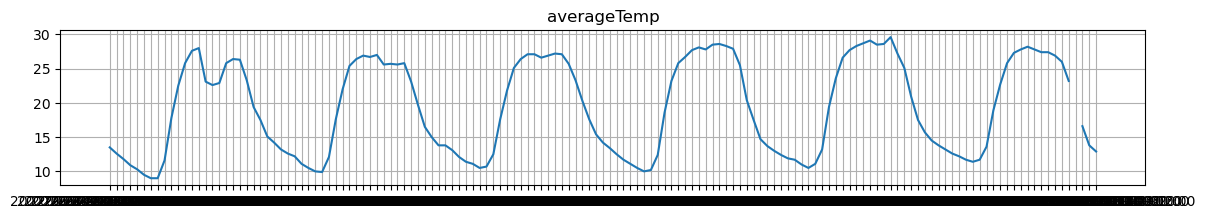

In [3]:
# ECVs, CREA getNearestStationData
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
#   outputs:
#    - dummy_cell_arg_o: String
# ...

import os
import sys
from datetime import datetime

import re
import requests
from io import BytesIO, StringIO
import json

import matplotlib.pyplot as plt
import pandas as pd
import shapely
import shapely.wkt

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-CREA getNearestStationData"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

input_crea_fun  = "getNearestStationData"
input_crea_data = {
    "startTime": param_start_date,
    "endTime":   param_end_date,
    "timeStep":  param_timestep,
    "wkt":       param_point_string,
    "limit":     param_crea_limit
}
input_crea_var  = f"{param_variable}"  # averageTemp

# output
# -----
dummy_cell_arg_o = "dummy output"

fname_fig = f'{input_crea_fun}.jpg'
file_result_fig = os.path.join(conf_minio_user_local_data, fname_fig)

# func
# -----
def call_restful_api(function, data={}, base_url="", key="", method='GET'):
    '''
    Calls a RESTful API
        Parameters:
            function (string): the name of the API method to invoke
            data (dictionary): the data payload
            bas_url (string):  the base addres of the API
            key (string):      the service key you registered
            method(string):    the HTTP method you want to use, defaults to POST

        Returns:
            service response (str or dictionary): Web service response, either a dictionary or a string.
    
    '''
    # set request headers    
    headers = {
        'Content-Type': 'application/json',
        'Ocp-Apim-Subscription-Key': key
    }

    # serialize request data into a json object
    payload  = json.dumps(data)
    response = None
    
    # invoke the Web Service
    if method == 'POST':
        response = requests.post(base_url + '/' + function, data=payload, headers=headers)
    else:
        response = requests.get( base_url + '/' + function, data=payload, headers=headers)
    if response.status_code == 200: # the 200 status means 'success'
        try:
            return {
                "code": 0,
                "text": "success",
                "data": response.json()
            }
        except:
            try:
                return  {
                "code": 0,
                "text": "success",
                "data": response.text
            }
            except:
                print('Unable to decode server response')
    else:
        print('Request failed with code ' + str(response.status_code))
    return {
        "code": 1,
        "text": "fail",
        "data": None
    }

# start
# -----
# r = anaee_api.call_restful_api(
r = call_restful_api(
    input_crea_fun,
    input_crea_data,
    key=secret_SERVICE_KEY,
    base_url=conf_SERVICE_URL_CREA,
    method=conf_SERVICE_METHOD_CREA)

if r["code"] == 0:
    # read the response into a data table
    df_data = pd.read_csv(StringIO(r["data"]))
    print(df_data.describe())
    print(df_data)
    
    # parse data
    # .....
    xs = df_data['date']
    ys = df_data[input_crea_var]
    
    # plot
    # .....
    plt.figure(figsize=(14,5))
    plt.axes().set_aspect('equal')
    # plt.title('Average Temperatures in C°')
    plt.title(f"{input_crea_var}")
    plt.grid()
    
    plt.plot(xs, ys)
    
    plt.savefig(file_result_fig)
    # plt.show()

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_result_fig}\n")

print(f"Finish: {workflow_step}")


workflow name
           seriesID   averageTemp       maxTemp       minTemp    windSpeed  \
count  22728.000000  20400.000000  17361.000000  17361.000000  5212.000000   
mean      10.980861     23.958245     25.053447     23.628328    16.164716   
std        0.137018      4.648323      4.503964      4.287589    12.982282   
min       10.000000      0.000000     11.000000     10.700000     0.000000   
25%       11.000000     20.500000     21.600000     20.400000     7.000000   
50%       11.000000     24.100000     25.200000     23.600000    14.000000   
75%       11.000000     27.600000     28.600000     26.900000    22.000000   
max       11.000000     36.200000     36.700000     35.800000    83.000000   

       maxWindSpeed     windGust  precipitation  stationPressure           RH  \
count    138.000000  4784.000000   22343.000000       283.000000  8807.000000   
mean       3.068116    33.329431       0.015844       991.239223    63.360395   
std        1.594699    20.105715       0

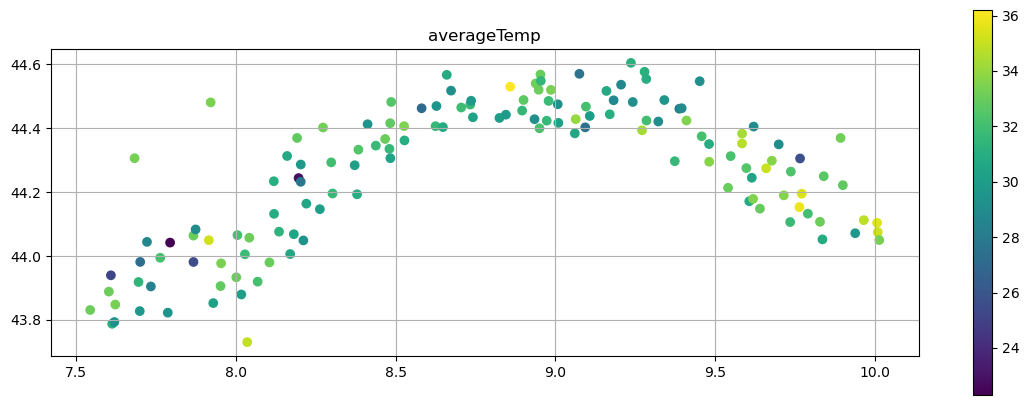

In [4]:
# ECVs, CREA getStationData
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
#   outputs:
#    - dummy_cell_arg_o: String
# ...

import os
import sys
from datetime import datetime

import re
import requests
from io import BytesIO, StringIO
import json

import matplotlib.pyplot as plt
import pandas as pd
import shapely
import shapely.wkt

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-CREA getStationData"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

input_crea_fun  = "getStationData"
input_crea_data = {
    "startTime": param_start_date,
    "endTime":   param_end_date,
    "timeStep":  param_timestep,
    "wkt":       param_polygon_string
}
input_crea_var  = f"{param_variable}"

# output
# -----
dummy_cell_arg_o = "dummy output"

fname_fig = f'{input_crea_fun}.jpg'
file_result_fig = os.path.join(conf_minio_user_local_data, fname_fig)

# func
# -----
def call_restful_api(function, data={}, base_url="", key="", method='GET'):
    '''
    Calls a RESTful API
        Parameters:
            function (string): the name of the API method to invoke
            data (dictionary): the data payload
            bas_url (string):  the base addres of the API
            key (string):      the service key you registered
            method(string):    the HTTP method you want to use, defaults to POST

        Returns:
            service response (str or dictionary): Web service response, either a dictionary or a string.
    
    '''
    # set request headers    
    headers = {
        'Content-Type': 'application/json',
        'Ocp-Apim-Subscription-Key': key
    }

    # serialize request data into a json object
    payload  = json.dumps(data)
    response = None
    
    # invoke the Web Service
    if method == 'POST':
        response = requests.post(base_url + '/' + function, data=payload, headers=headers)
    else:
        response = requests.get( base_url + '/' + function, data=payload, headers=headers)
    if response.status_code == 200: # the 200 status means 'success'
        try:
            return {
                "code": 0,
                "text": "success",
                "data": response.json()
            }
        except:
            try:
                return  {
                "code": 0,
                "text": "success",
                "data": response.text
            }
            except:
                print('Unable to decode server response')
    else:
        print('Request failed with code ' + str(response.status_code))
    return {
        "code": 1,
        "text": "fail",
        "data": None
    }

def parse_wkt_point(geom_string):
    '''
    Parse the POINT (Lon Lat)
    '''
    try:
        m = re.search(r'(\d+\.?\d*)\s+(\d+\.?\d*)', geom_string)
        lon = m.group(1)
        lat = m.group(2)
        return lon, lat
    except:
        return None, None

# start
# -----
# r = anaee_api.call_restful_api(
r = call_restful_api(
    input_crea_fun,
    input_crea_data,
    key=secret_SERVICE_KEY,
    base_url=conf_SERVICE_URL_CREA,
    method=conf_SERVICE_METHOD_CREA)

if r["code"] == 0:
    # read the response into a data table
    df_data = pd.read_csv(StringIO(r["data"]))
    print(df_data.describe())
    print(df_data)
    
    # parse data
    # .....
    values = df_data.groupby('geography')[input_crea_var].max()
    
    xs = []
    ys = []
    for location in values.index:
        # x, y = anaee_api.parse_wkt_point(location)
        x, y = parse_wkt_point(location)
        xs.append(float(x))
        ys.append(float(y))
        
    # plot
    # .....
    plt.figure(figsize=(14,5))
    plt.axes().set_aspect('equal')
    # plt.title('Average Temperatures in C°')
    plt.title(f"{input_crea_var}")
    plt.grid()
    
    plt.scatter(xs, ys, c=values, marker="o", cmap="viridis")
    plt.colorbar()
    
    plt.savefig(file_result_fig)
    # plt.show()

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_result_fig}\n")

print(f"Finish: {workflow_step}")


In [5]:
# ECVs, CREA getRasterData
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
#   outputs:
#    - dummy_cell_arg_o: String
# ...

import os
import sys
from datetime import datetime

import re
import requests
from io import BytesIO, StringIO
import json

import matplotlib.pyplot as plt
import pandas as pd
import shapely
import shapely.wkt

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-CREA getRasterData"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

input_crea_fun  = "getRasterData"
input_crea_data = {
    "startTime": param_start_date,
    "endTime":   param_end_date,
    "timeStep":  param_timestep,
    "wkt":       param_polygon_string,
    "group":     param_crea_group
}
input_crea_var  = f"{param_variable}"

# output
# -----
dummy_cell_arg_o = "dummy output"

fname_fig = f'{input_crea_fun}.jpg'
file_result_fig = os.path.join(conf_minio_user_local_data, fname_fig)

# func
# -----
def call_restful_api(function, data={}, base_url="", key="", method='GET'):
    '''
    Calls a RESTful API
        Parameters:
            function (string): the name of the API method to invoke
            data (dictionary): the data payload
            bas_url (string):  the base addres of the API
            key (string):      the service key you registered
            method(string):    the HTTP method you want to use, defaults to POST

        Returns:
            service response (str or dictionary): Web service response, either a dictionary or a string.
    
    '''
    # set request headers    
    headers = {
        'Content-Type': 'application/json',
        'Ocp-Apim-Subscription-Key': key
    }

    # serialize request data into a json object
    payload  = json.dumps(data)
    response = None
    
    # invoke the Web Service
    if method == 'POST':
        response = requests.post(base_url + '/' + function, data=payload, headers=headers)
    else:
        response = requests.get( base_url + '/' + function, data=payload, headers=headers)
    if response.status_code == 200: # the 200 status means 'success'
        try:
            return {
                "code": 0,
                "text": "success",
                "data": response.json()
            }
        except:
            try:
                return  {
                "code": 0,
                "text": "success",
                "data": response.text
            }
            except:
                print('Unable to decode server response')
    else:
        print('Request failed with code ' + str(response.status_code))
    return {
        "code": 1,
        "text": "fail",
        "data": None
    }

def parse_wkt_point(geom_string):
    '''
    Parse the POINT (Lon Lat)
    '''
    try:
        m = re.search(r'(\d+\.?\d*)\s+(\d+\.?\d*)', geom_string)
        lon = m.group(1)
        lat = m.group(2)
        return lon, lat
    except:
        return None, None

# start
# -----
# r = anaee_api.call_restful_api(
r = call_restful_api(
    input_crea_fun,
    input_crea_data,
    key=secret_SERVICE_KEY,
    base_url=conf_SERVICE_URL_CREA,
    method=conf_SERVICE_METHOD_CREA)

if r["code"] == 0:
    # read the response into a data table
    df_data = pd.read_csv(StringIO(r["data"]))
    print(df_data.describe())
    print(df_data)
    
    # parse data
    # .....
    values = df_data.groupby('geography')[input_crea_var].max()
    
    xs = []
    ys = []
    for location in values.index:
        # x, y = anaee_api.parse_wkt_point(location)
        x, y = parse_wkt_point(location)
        xs.append(float(x))
        ys.append(float(y))
    
    # plot
    # .....
    plt.figure(figsize=(14,5))
    plt.axes().set_aspect('equal')
    # plt.title('Maximum Temperatures in C°')
    plt.title(f"{input_crea_var}")
    plt.grid()
    
    plt.scatter(xs, ys, c=values, marker="o", cmap="viridis")
    plt.colorbar()
    
    plt.savefig(file_result_fig)
    # plt.show()

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_result_fig}\n")

print(f"Finish: {workflow_step}")


workflow name
Request failed with code 400
Finish: ECVs-CREA getRasterData


In [6]:
# ECVs, ERA5 GetEraData
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
#   outputs:
#    - dummy_cell_arg_o: String
# ...

import os
import sys
from datetime import datetime

import re
import requests
from io import BytesIO, StringIO
import json

import matplotlib.pyplot as plt
import pandas as pd
import shapely
import shapely.wkt

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-ERA5 GetEraData"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

input_era5_fun = "GetEraData"
input_era5_data = {
    "startTime": param_start_date,
    "endTime":   param_end_date,
    "timeStep":  param_timestep,
    "wkt":       param_polygon_string
}
input_era5_var  = f"{param_variable}"  # 't2m'

# output
# -----
dummy_cell_arg_o = "dummy output"

fname_fig_1 = f'{input_era5_fun}-scatter.jpg'
file_result_fig_1 = os.path.join(conf_minio_user_local_data, fname_fig_1)

fname_fig_2 = f'{input_era5_fun}-line.jpg'
file_result_fig_2 = os.path.join(conf_minio_user_local_data, fname_fig_2)

# func
# -----
def call_restful_api(function, data={}, base_url="", key="", method='GET'):
    '''
    Calls a RESTful API
        Parameters:
            function (string): the name of the API method to invoke
            data (dictionary): the data payload
            bas_url (string):  the base addres of the API
            key (string):      the service key you registered
            method(string):    the HTTP method you want to use, defaults to POST

        Returns:
            service response (str or dictionary): Web service response, either a dictionary or a string.
    
    '''
    # set request headers    
    headers = {
        'Content-Type': 'application/json',
        'Ocp-Apim-Subscription-Key': key
    }

    # serialize request data into a json object
    payload  = json.dumps(data)
    response = None
    
    # invoke the Web Service
    if method == 'POST':
        response = requests.post(base_url + '/' + function, data=payload, headers=headers)
    else:
        response = requests.get( base_url + '/' + function, data=payload, headers=headers)
    if response.status_code == 200: # the 200 status means 'success'
        try:
            return {
                "code": 0,
                "text": "success",
                "data": response.json()
            }
        except:
            try:
                return  {
                "code": 0,
                "text": "success",
                "data": response.text
            }
            except:
                print('Unable to decode server response')
    else:
        print('Request failed with code ' + str(response.status_code))
    return {
        "code": 1,
        "text": "fail",
        "data": None
    }

def parse_wkt_point(geom_string):
    '''
    Parse the POINT (Lon Lat)
    '''
    try:
        m = re.search(r'(\d+\.?\d*)\s+(\d+\.?\d*)', geom_string)
        lon = m.group(1)
        lat = m.group(2)
        return lon, lat
    except:
        return None, None

# start
# -----
# r = anaee_api.call_restful_api(
r = call_restful_api(
    input_era5_fun,
    input_era5_data,
    key=secret_SERVICE_KEY,
    base_url=conf_SERVICE_URL_ERA5,
    method=conf_SERVICE_METHOD_ERA5)

if r["code"] == 0:
    # read the response into a data table
    df_data = pd.read_csv(StringIO(r["data"]))
    print(df_data.describe())
    print(df_data)
    
    # parse data
    # .....
    values = df_data.groupby('geometry')[input_era5_var].max()
    
    xs = []
    ys = []
    for location in values.index:
        # x, y = anaee_api.parse_wkt_point(location)
        x, y = parse_wkt_point(location)
        xs.append(float(x))
        ys.append(float(y))
        
    # plot scatter
    # .....
    plt.figure(figsize=(14,5))
    plt.axes().set_aspect('equal')
    # plt.title('Maximum Temperatures in C°')
    plt.title(f"{input_era5_var}")
    plt.grid()
    plt.scatter(xs, ys, c=values, marker="o", cmap="viridis")
    plt.colorbar()
    
    # output
    # .....
    plt.savefig(file_result_fig_1)
    # plt.show()
    
    # plot line
    # .....
    cell_data = df_data.loc[df_data['geometry'] == 'POINT(9.0 44.5)']
    cell_data.index = cell_data['Date']
    
    plt.figure(figsize = (14, 5))
    cell_data[input_era5_var].plot()
    
    # output
    # .....
    plt.savefig(file_result_fig_2)
    # plt.show()

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_result_fig_1}\n")
    fp_log.write(f"\nOutput: {file_result_fig_2}\n")

print(f"Finish: {workflow_step}")


workflow name
         Elevation     Latitude    Longitude          d2m          t2m  \
count  3456.000000  3456.000000  3456.000000  3456.000000  3456.000000   
mean    428.423443    44.208333     8.677083    18.526383    23.642768   
std     283.207578     0.246539     0.775647     2.466437     2.649416   
min      19.457863    43.750000     7.500000    10.584356    15.031815   
25%     200.957629    44.000000     8.000000    16.888007    22.304023   
50%     426.737755    44.250000     8.500000    18.685059    23.864961   
75%     568.947305    44.500000     9.312500    20.412552    25.244018   
max    1095.455317    44.500000    10.000000    24.374722    33.650583   

               u10          v10          ssrd           tp           rh  \
count  3456.000000  3456.000000  3.456000e+03  3456.000000  3456.000000   
mean     -0.384085     0.723748  1.085031e+06     0.000011     0.742680   
std       1.482533     1.677216  1.156580e+06     0.000078     0.127558   
min      -6.243634 

KeyError: 'Column not found: averageTemp'

In [ ]:
# Don't containerize
# =====

print(param_workflow_name)

# output
# -----
fname_fig = 'polygon.jpg'
file_result_fig = os.path.join(conf_minio_user_local_data, fname_fig)

# plot polygon
# .....
P = shapely.wkt.loads(param_polygon_string)

plt.figure(figsize=(8,5))
plt.axes().set_aspect('equal')
plt.plot(*P.exterior.xy)

# output
# .....
plt.savefig(file_result_fig)
# plt.show()

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {file_result_fig}\n")

print(f"Finish: {workflow_step}")


In [ ]:
# ECVs, workflow finish
# ---
# NaaVRE:
#  cell:
#   inputs:
#    - dummy_cell_arg_i: String
# ...

import os
import sys
from datetime import datetime

# sys.path.append(conf_minio_public_local_code)
# sys.path.append(conf_minio_user_local_code)

print(param_workflow_name)
workflow_step = f"{conf_vlab_name}-Finish"

if os.path.exists(conf_minio_user_local_flog):
    with open(conf_minio_user_local_flog, "a+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 
else:
    if not os.path.exists(conf_minio_user_local_data):
        os.makedirs(conf_minio_user_local_data)
    with open(conf_minio_user_local_flog, "w+") as fp_log:
        fp_log.write(f"\n## {workflow_step}\n") 

# lib, minio_public
# -----
# sys.path.append(conf_minio_public_local_code)

# lib, minio_user
# -----
# sys.path.append(conf_minio_user_local_code)

# input
# -----
dummy_cell_arg_i = "dummy input"

# output
# -----
dummy_cell_arg_o = "dummy output"

# func
# -----

# start
# -----

# -----
with open(conf_minio_user_local_flog, "a+") as fp_log:
    fp_log.write(f"\nFinish: {workflow_step}\n")
    fp_log.write(f"\nOutput: {conf_minio_user_local_data}\n")

print(f"Finish: {workflow_step}")
